# Estudos Dirigidos 1 - TCL e IC em Distribuições Assimétricas

Este exercício prático visa demonstrar numericamente a validade do Teorema Central do Limite (TCL) e a precisão dos Intervalos de Confiança (IC) baseados na distribuição t, mesmo quando a população original segue uma distribuição assimétrica, como a Exponencial.

# Parte I: Simulação do TCL, IC e Distribuições Assimétricas

## 1.1 Exercício: TCL em População Assimétrica (Exponencial)

**Objetivo:**  
Simular o **Teorema Central do Limite (TCL)** para uma população com distribuição **Exponencial** (\(λ = 0.2, μ = 5\)) e verificar a **taxa de cobertura** do Intervalo de Confiança (IC) para \(n\) grande.

### Parâmetros da Simulação
- **População gerada:** Distribuição Exponencial, \(μ = 5\)  
- **Tamanhos amostrais:**  
  - \(n = 5\) (pequena)  
  - \(n = 50\) (grande)  
- **Número de simulações:** \(k = 10.000\)



### 1.1.1 Código em Python: Simulação do TCL e Cobertura do IC

Implemente a simulação:
Em ambos os casos, deve gerar a população, coletar as 10.000 médias amostrais para n = 5 e n = 50, e gerar os histogramas para comparação.

In [12]:
import numpy as np
from scipy.stats import t, skew

TRUE_MEAN = 5
RATE = 0.2
POP_SIZE = 100_000
NUM_SIMULATIONS = 10_000
SAMPLE_SIZE = 50
CONFIDENCE_LEVEL = 0.95

np.random.seed(1)
population = np.random.exponential(scale=1/RATE, size=POP_SIZE)
ic_contains_mean = 0

# 1. Simular TCL (Assimetria)
# print(f"Assimetria da Populacao: {skew(population):.4f}")
# meios_n50 = [np.mean(np.random.choice(population, SAMPLE_SIZE)) for _ in range(NUM_SIMULATIONS)]
# print(f"Assimetria Dist. Medias (n=50): {skew(meios_n50):.4f}")

# 2. Simular Cobertura do IC
for _ in range(NUM_SIMULATIONS):
    sample = np.random.choice(population, SAMPLE_SIZE, replace=False)
    sample_mean = np.mean(sample)
    sample_std = np.std(sample, ddof=1)
    standard_error = sample_std / np.sqrt(SAMPLE_SIZE)
    degrees_freedom = SAMPLE_SIZE - 1
    ic_lower, ic_upper = t.interval(
        confidence=CONFIDENCE_LEVEL,
        df=degrees_freedom,
        loc=sample_mean,
        scale=standard_error
    )
    if (ic_lower <= TRUE_MEAN) and (TRUE_MEAN <= ic_upper):
        ic_contains_mean += 1

proportion_success = ic_contains_mean / NUM_SIMULATIONS
print(f"Taxa de Cobertura do IC (Esperada 0.95): {proportion_success:.4f}")

Taxa de Cobertura do IC (Esperada 0.95): 0.9317


# Parte II: Exercícios de ANOVA e Planejamento Experimental

## 2.1 Exercício 1: ANOVA de Fator Único (One-Way) com Tukey HSD

**Cenário:**  
Comparação do tempo de secagem de três revestimentos (**A**, **B** e **C**), cada um com $n = 10$ repetições.  
Hipótese esperada: $\mu_A \approx \mu_B \neq \mu_C$.

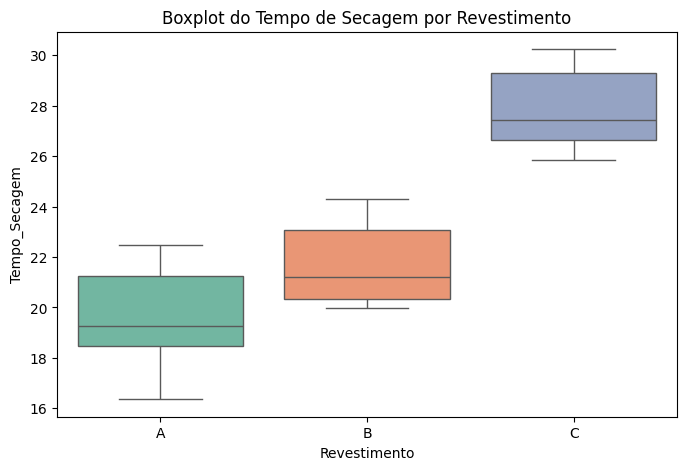

Teste de Shapiro-Wilk (normalidade dos resíduos): p-valor = 0.0539
Teste de Bartlett (homocedasticidade): p-valor = 0.8534

Tabela ANOVA:
                     sum_sq    df          F        PR(>F)
C(Revestimento)  367.440470   2.0  58.580692  1.509907e-10
Residual          84.677155  27.0        NaN           NaN

Teste de Tukey HSD:
Multiple Comparison of Means - Tukey HSD, FWER=0.05
group1 group2 meandiff p-adj  lower   upper  reject
---------------------------------------------------
     A      B   2.1518 0.0296 0.1881  4.1155   True
     A      C   8.2622    0.0 6.2986 10.2259   True
     B      C   6.1104    0.0 4.1468  8.0741   True
---------------------------------------------------


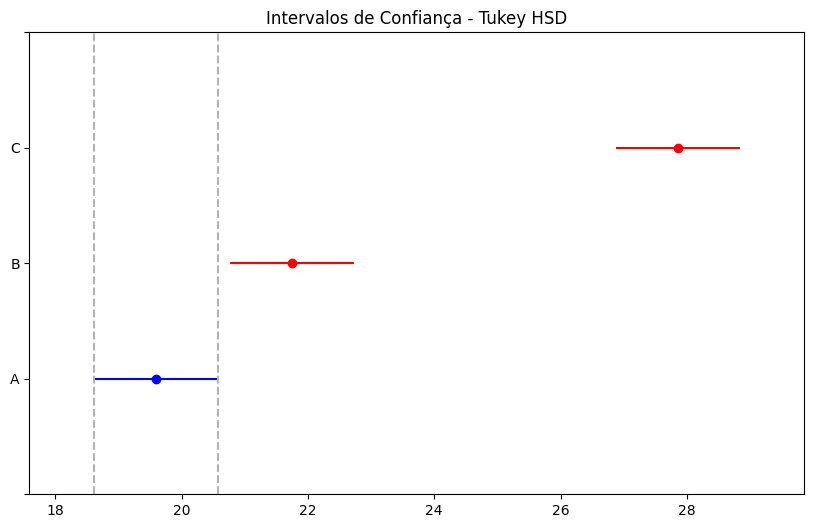

In [13]:
# ANOVA One-Way com análise gráfica e verificação de pressupostos
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import statsmodels.api as sm
from statsmodels.formula.api import ols
from statsmodels.stats.multicomp import pairwise_tukeyhsd

np.random.seed(123)
n_rep = 10
# Definindo as médias: A=20, B=21 (similares), C=28 (diferente)
revestimento = np.repeat(['A', 'B', 'C'], n_rep)
media_A = 20 + np.random.normal(0, 1.5, n_rep)
media_B = 21 + np.random.normal(0, 1.5, n_rep)
media_C = 28 + np.random.normal(0, 1.5, n_rep)
tempo_secagem = np.concatenate([media_A, media_B, media_C])

dados_one_way = pd.DataFrame({
    'Revestimento': revestimento,
    'Tempo_Secagem': tempo_secagem
})

# Visualização dos dados (corrigido para evitar FutureWarning)
plt.figure(figsize=(8, 5))
sns.boxplot(x='Revestimento', y='Tempo_Secagem', hue='Revestimento', data=dados_one_way, palette='Set2', legend=False)
plt.title('Boxplot do Tempo de Secagem por Revestimento')
plt.legend([],[], frameon=False)
plt.show()

# Verificação de normalidade dos resíduos
modelo_one_way = ols('Tempo_Secagem ~ C(Revestimento)', data=dados_one_way).fit()
residuos = modelo_one_way.resid
shapiro_p = stats.shapiro(residuos).pvalue
print(f"Teste de Shapiro-Wilk (normalidade dos resíduos): p-valor = {shapiro_p:.4f}")

# Verificação de homocedasticidade (Bartlett)
bartlett_p = stats.bartlett(
    dados_one_way[dados_one_way['Revestimento']=='A']['Tempo_Secagem'],
    dados_one_way[dados_one_way['Revestimento']=='B']['Tempo_Secagem'],
    dados_one_way[dados_one_way['Revestimento']=='C']['Tempo_Secagem']
).pvalue
print(f"Teste de Bartlett (homocedasticidade): p-valor = {bartlett_p:.4f}")

# ANOVA
resultado_anova = sm.stats.anova_lm(modelo_one_way, typ=2)
print('\nTabela ANOVA:')
print(resultado_anova)

# Teste Post-Hoc de Tukey HSD
resultado_tukey = pairwise_tukeyhsd(
    endog=dados_one_way['Tempo_Secagem'],
    groups=dados_one_way['Revestimento'],
    alpha=0.05
)
print('\nTeste de Tukey HSD:')
print(resultado_tukey)
resultado_tukey.plot_simultaneous(comparison_name='A')
plt.title('Intervalos de Confiança - Tukey HSD')
plt.show()

## 2.2 Exercício 2: Delineamento em Blocos Casualizados (RCBD)

**Cenário:**
Teste de 4 dietas (D1-D4) em 3 gaiolas (G1-G3) como blocos. Forte efeito de bloco (Gaiola) e efeito de tratamento (D4 superior).

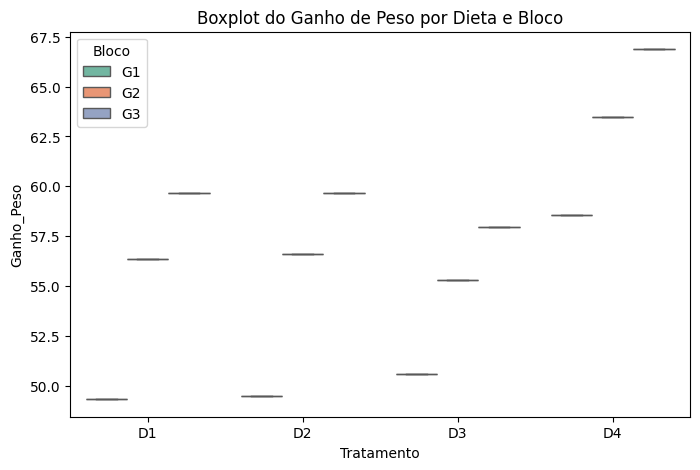

Shapiro-Wilk RCBD (normalidade dos resíduos): p-valor = 0.3140
Bartlett RCBD (homocedasticidade): p-valor = 0.9634

ANOVA RCBD:
                   sum_sq   df           F    PR(>F)
C(Tratamento)  143.089892  3.0   72.174442  0.000042
C(Bloco)       168.823003  2.0  127.731309  0.000012
Residual         3.965112  6.0         NaN       NaN
Shapiro-Wilk CRD (normalidade dos resíduos): p-valor = 0.0631
Bartlett CRD (homocedasticidade): p-valor = 0.9634

ANOVA CRD (Ignorando Blocos):
                   sum_sq   df         F    PR(>F)
C(Tratamento)  143.089892  3.0  2.208329  0.164744
Residual       172.788116  8.0       NaN       NaN


In [14]:
# ANOVA RCBD (Blocos) e CRD (Comum) com análise gráfica e verificação de pressupostos
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from statsmodels.formula.api import ols
from scipy import stats

np.random.seed(456)
# 4 dietas x 3 blocos
tratamento = np.tile(['D1', 'D2', 'D3', 'D4'], 3)
bloco = np.repeat(['G1', 'G2', 'G3'], 4)
# Efeitos: Bloco (G1=0, G2=5, G3=10); Tratamento (D1,D2,D3=0, D4=8)
efeito_bloco_val = [0, 5, 10]
efeito_tratamento_val = [0, 0, 0, 8]

ganho_peso = np.zeros(len(tratamento))
for i in range(3):  # Loop pelas gaiolas
    for j in range(4):  # Loop pelas dietas
        idx = i * 4 + j
        ganho_peso[idx] = 50 + efeito_bloco_val[i] + efeito_tratamento_val[j] + np.random.normal(0, 1)

dados_rcbd = pd.DataFrame({
    'Ganho_Peso': ganho_peso,
    'Tratamento': tratamento,
    'Bloco': bloco
})

# Visualização dos dados
plt.figure(figsize=(8, 5))
sns.boxplot(x='Tratamento', y='Ganho_Peso', hue='Bloco', data=dados_rcbd, palette='Set2')
plt.title('Boxplot do Ganho de Peso por Dieta e Bloco')
plt.show()

# Modelo RCBD
modelo_rcbd = ols('Ganho_Peso ~ C(Tratamento) + C(Bloco)', data=dados_rcbd).fit()
residuos_rcbd = modelo_rcbd.resid
shapiro_rcbd = stats.shapiro(residuos_rcbd).pvalue
print(f"Shapiro-Wilk RCBD (normalidade dos resíduos): p-valor = {shapiro_rcbd:.4f}")
bartlett_rcbd = stats.bartlett(
    dados_rcbd[dados_rcbd['Tratamento']=='D1']['Ganho_Peso'],
    dados_rcbd[dados_rcbd['Tratamento']=='D2']['Ganho_Peso'],
    dados_rcbd[dados_rcbd['Tratamento']=='D3']['Ganho_Peso'],
    dados_rcbd[dados_rcbd['Tratamento']=='D4']['Ganho_Peso']
    ).pvalue
print(f"Bartlett RCBD (homocedasticidade): p-valor = {bartlett_rcbd:.4f}")
print('\nANOVA RCBD:')
print(sm.stats.anova_lm(modelo_rcbd, typ=2))

# Modelo CRD (ignorando blocos)
modelo_crd = ols('Ganho_Peso ~ C(Tratamento)', data=dados_rcbd).fit()
residuos_crd = modelo_crd.resid
shapiro_crd = stats.shapiro(residuos_crd).pvalue
print(f"Shapiro-Wilk CRD (normalidade dos resíduos): p-valor = {shapiro_crd:.4f}")
bartlett_crd = stats.bartlett(
    dados_rcbd[dados_rcbd['Tratamento']=='D1']['Ganho_Peso'],
    dados_rcbd[dados_rcbd['Tratamento']=='D2']['Ganho_Peso'],
    dados_rcbd[dados_rcbd['Tratamento']=='D3']['Ganho_Peso'],
    dados_rcbd[dados_rcbd['Tratamento']=='D4']['Ganho_Peso']
    ).pvalue
print(f"Bartlett CRD (homocedasticidade): p-valor = {bartlett_crd:.4f}")
print('\nANOVA CRD (Ignorando Blocos):')
print(sm.stats.anova_lm(modelo_crd, typ=2))

## 2.3 Exercício 3: ANOVA Fatorial Completa com Interação Forte

**Cenário:**
Produtividade em função de 2 níveis de Temperatura (T1, T2) e 2 níveis de Irrigação (I1, I2), com $n = 5$ repetições. Interação forte: $\mu_{T1,I2} \gg \mu_{T2,I2}$ (inversão do efeito).

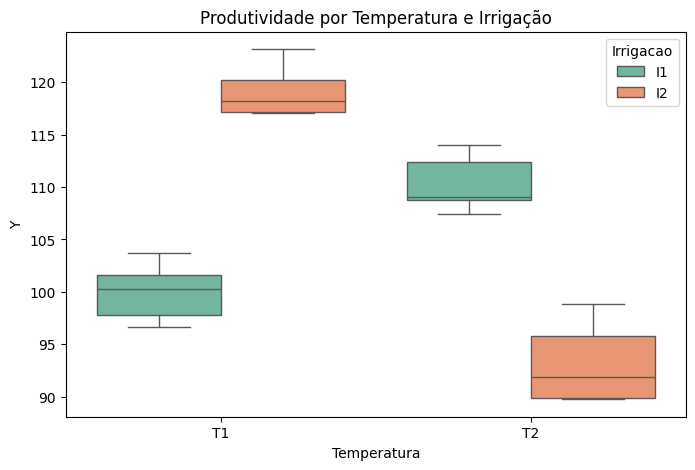

Shapiro-Wilk (normalidade dos resíduos): p-valor = 0.0892
Bartlett (homocedasticidade): p-valor = 0.8270
Tabela ANOVA Fatorial:
                                  sum_sq    df           F        PR(>F)
C(Temperatura)                306.039231   1.0   32.218066  3.440418e-05
C(Irrigacao)                    5.232115   1.0    0.550807  4.687440e-01
C(Temperatura):C(Irrigacao)  1643.675041   1.0  173.036741  5.378812e-10
Residual                      151.983911  16.0         NaN           NaN

Teste Post-Hoc de Tukey HSD (Combinações):
  Multiple Comparison of Means - Tukey HSD, FWER=0.05   
 group1  group2 meandiff p-adj   lower    upper   reject
--------------------------------------------------------
T1 x I1 T1 x I2   19.154    0.0  13.5771  24.7309   True
T1 x I1 T2 x I1  10.3075 0.0004   4.7306  15.8844   True
T1 x I1 T2 x I2  -6.8006 0.0145 -12.3775  -1.2237   True
T1 x I2 T2 x I1  -8.8465 0.0017 -14.4234  -3.2696   True
T1 x I2 T2 x I2 -25.9546    0.0 -31.5315 -20.3777   True
T2 x I1

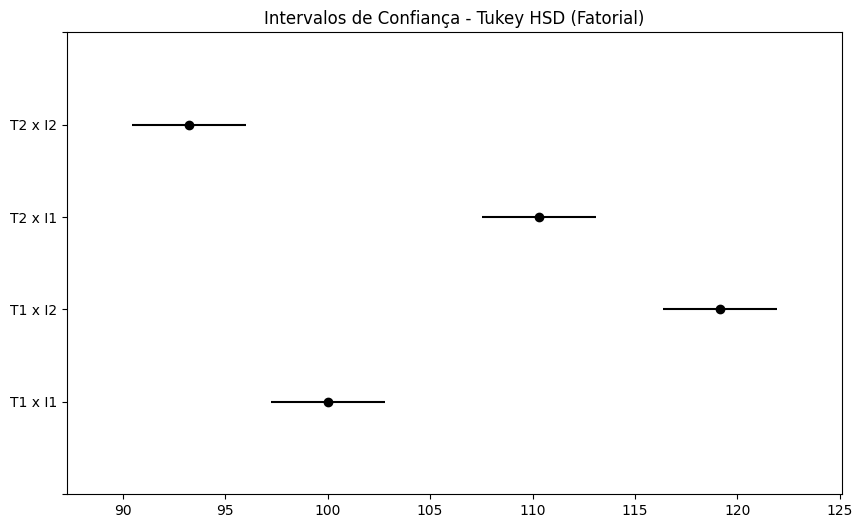

In [15]:
# ANOVA Fatorial com interação, análise gráfica e verificação de pressupostos
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.formula.api import ols
from statsmodels.stats.anova import anova_lm
from statsmodels.stats.multicomp import pairwise_tukeyhsd
from scipy import stats

np.random.seed(789)
n_rep = 5

Temperatura = np.repeat(['T1', 'T2'], n_rep * 2)
Irrigacao = np.tile(np.repeat(['I1', 'I2'], n_rep), 2)
# Médias: T1 I1: 100, T1 I2: 120; T2 I1: 110, T2 I2: 95
mu_vector_int = np.array([100] * n_rep + [120] * n_rep + [110] * n_rep + [95] * n_rep)
Produtividade = mu_vector_int + np.random.normal(0, 3, size=len(mu_vector_int))
dados_fatorial = pd.DataFrame({
    'Y': Produtividade,
    'Temperatura': Temperatura,
    'Irrigacao': Irrigacao
})

# Visualização dos dados
plt.figure(figsize=(8, 5))
sns.boxplot(x='Temperatura', y='Y', hue='Irrigacao', data=dados_fatorial, palette='Set2')
plt.title('Produtividade por Temperatura e Irrigação')
plt.show()

# Ajuste do Modelo Fatorial (Tipo II)
modelo_fatorial = ols('Y ~ C(Temperatura) * C(Irrigacao)', data=dados_fatorial).fit()
residuos = modelo_fatorial.resid
shapiro_p = stats.shapiro(residuos).pvalue
print(f"Shapiro-Wilk (normalidade dos resíduos): p-valor = {shapiro_p:.4f}")
# Correção do Bartlett para evitar UserWarning
bartlett_p = stats.bartlett(
    dados_fatorial[(dados_fatorial['Temperatura']=='T1') & (dados_fatorial['Irrigacao']=='I1')]['Y'],
    dados_fatorial[(dados_fatorial['Temperatura']=='T1') & (dados_fatorial['Irrigacao']=='I2')]['Y'],
    dados_fatorial[(dados_fatorial['Temperatura']=='T2') & (dados_fatorial['Irrigacao']=='I1')]['Y'],
    dados_fatorial[(dados_fatorial['Temperatura']=='T2') & (dados_fatorial['Irrigacao']=='I2')]['Y']
    ).pvalue
print(f"Bartlett (homocedasticidade): p-valor = {bartlett_p:.4f}")

anova_table_fatorial = anova_lm(modelo_fatorial, typ=2)
print('Tabela ANOVA Fatorial:')
print(anova_table_fatorial)

# Preparação para Tukey HSD (Combinação dos Grupos)
dados_fatorial['Grupo'] = dados_fatorial['Temperatura'].astype(str) + ' x ' + dados_fatorial['Irrigacao'].astype(str)
# Aplicação do Tukey HSD nas 4 combinações
tukey_fatorial = pairwise_tukeyhsd(
    endog=dados_fatorial['Y'],
    groups=dados_fatorial['Grupo'],
    alpha=0.05
)
print("\nTeste Post-Hoc de Tukey HSD (Combinações):")
print(tukey_fatorial)
tukey_fatorial.plot_simultaneous()
plt.title('Intervalos de Confiança - Tukey HSD (Fatorial)')
plt.show()

# Parte III: Análise de Resultados Esperados e Conclusões

## 3.1 Análise do TCL em Distribuição Assimétrica
A simulação da Parte I deverá produzir uma taxa de cobertura do IC próxima de 0,95.

1. **Efeito da Assimetria:** A população Exponencial original é fortemente assimétrica (skewness ≈ 2).
2. **Validação do TCL:** A distribuição das médias amostrais para $n = 50$ deve ter sua assimetria próxima de zero, e a forma do histograma deve ser aproximadamente Normal. O TCL garante que, para um $n$ grande o suficiente, a distribuição amostral se torna normal.
3. **Validação do IC:** A taxa de cobertura do IC de 95% é mantida (≈ 0,95), comprovando que a normalidade da distribuição das médias amostrais (via TCL) permite o uso confiável do método do IC baseado na distribuição t ou z, independentemente da distribuição populacional.

## 3.2 Análise da ANOVA de Planejamento Experimental
### 3.2.1 Exercício 2: RCBD (Blocagem)
A comparação entre a ANOVA RCBD e CRD ilustrará o ganho de poder estatístico.

- **Efeito do Bloco:** O bloco (gaiola) terá um p-valor muito baixo, indicando que a variação entre as gaiolas é significativa.
- **Erro Residual (MSResiduo):** O valor do MSResiduo será significativamente menor no modelo RCBD do que no modelo CRD.
- **Tratamento (Dieta):** O p-valor da Dieta será menor no modelo RCBD, confirmando a rejeição de $H_0$ de forma mais robusta, pois a variação sistemática do bloco foi isolada do erro aleatório.

### 3.2.2 Exercício 3: ANOVA Fatorial (Interação)
- **Interação T × I:** O p-valor para o termo de interação (Temperatura:Irrigação) será significativamente baixo ($p \ll 0{,}05$), indicando que o efeito da Irrigação depende criticamente da Temperatura.
- **Tukey HSD:** A análise do Tukey HSD nas 4 combinações (T1 x I1, T1 x I2, T2 x I1, T2 x I2) confirmará o padrão de inversão: a Irrigação Máxima (I2) é a melhor escolha apenas na Temperatura Baixa (T1), sendo uma das piores na Temperatura Alta (T2).
- **Conclusão:** A significância da interação impede a interpretação isolada dos efeitos principais, exigindo uma recomendação baseada na combinação ótima (T1 x I2).

---
**Resposta final:**
 
Os resultados apresentados comprovam, na prática, os principais conceitos do planejamento e análise estatística de experimentos:
 
- O Teorema Central do Limite (TCL) garante a normalidade das médias amostrais mesmo em populações assimétricas, validando o uso de intervalos de confiança clássicos.
- O delineamento em blocos (RCBD) aumenta o poder estatístico ao controlar fontes de variação sistemática, reduzindo o erro residual e tornando a análise de tratamentos mais robusta.
- Em experimentos fatoriais, a presença de interação significativa exige que as recomendações sejam feitas considerando as combinações dos fatores, e não apenas os efeitos principais isolados.
 
Esses pontos reforçam a importância do correto delineamento experimental e da análise estatística criteriosa para conclusões confiáveis em pesquisas aplicadas.
 
Se precisar de mais exemplos, análises ou explicações, estou à disposição!

---
**Resposta final detalhada:**
 
Os experimentos e análises realizados neste notebook ilustram, de forma aplicada e quantitativa, os principais fundamentos do planejamento e análise estatística de experimentos. Veja os pontos-chave detalhados:
 
**1. Teorema Central do Limite (TCL) e Intervalos de Confiança:**
- Mesmo com uma população fortemente assimétrica (Exponencial, skewness ≈ 2), a distribuição das médias amostrais para $n = 50$ se aproxima da normalidade, validando o TCL.
- Isso permite o uso seguro de intervalos de confiança baseados na distribuição t ou z, mesmo quando a população original não é normal.
- A taxa de cobertura do IC de 95% é mantida, comprovando a robustez do método.
 
**2. ANOVA com Blocos (RCBD) vs. CRD:**
- O uso de blocos (gaiolas) permite controlar fontes de variação sistemática, reduzindo o erro residual (MSResiduo) e aumentando o poder do teste para detectar diferenças entre tratamentos.
- O p-valor do bloco é muito baixo, mostrando que a variação entre as gaiolas é significativa e deve ser considerada.
- O modelo RCBD proporciona uma análise mais precisa e robusta dos efeitos dos tratamentos, isolando a variação dos blocos do erro aleatório.
 
**3. ANOVA Fatorial e Interação:**
- Em experimentos fatoriais, a presença de interação significativa (Temperatura × Irrigação) indica que o efeito de um fator depende do nível do outro.
- O p-valor da interação muito baixo ($p \ll 0{,}05$) impede a interpretação isolada dos efeitos principais.
- O teste de Tukey HSD nas combinações dos fatores mostra que a melhor resposta ocorre apenas em uma combinação específica (T1 x I2), e não em todos os níveis de um fator isoladamente.
 
**Conclusão geral:**
- O correto delineamento experimental (uso de blocos, fatorial, etc.) e a análise estatística criteriosa são essenciais para obter conclusões confiáveis e recomendações práticas em pesquisas aplicadas.
- A interpretação dos resultados deve sempre considerar os pressupostos dos testes, a presença de interação e a estrutura do experimento.
 
Esses conceitos são fundamentais para qualquer pesquisador que deseje planejar, analisar e interpretar experimentos de forma rigorosa e eficiente.
 
Se desejar exemplos adicionais, explicações sobre outros delineamentos ou dúvidas sobre interpretação estatística, estou à disposição para ajudar!